Loading LCMS collection with 22 samples using 8  cores
Time to load LCMS collection  181.71068596839905 seconds - 22  LCMS runs and  8  cores
Number of total mass features:  151007
Aligning LCMS collection
Time to align LCMS collection:  12.283224821090698 seconds


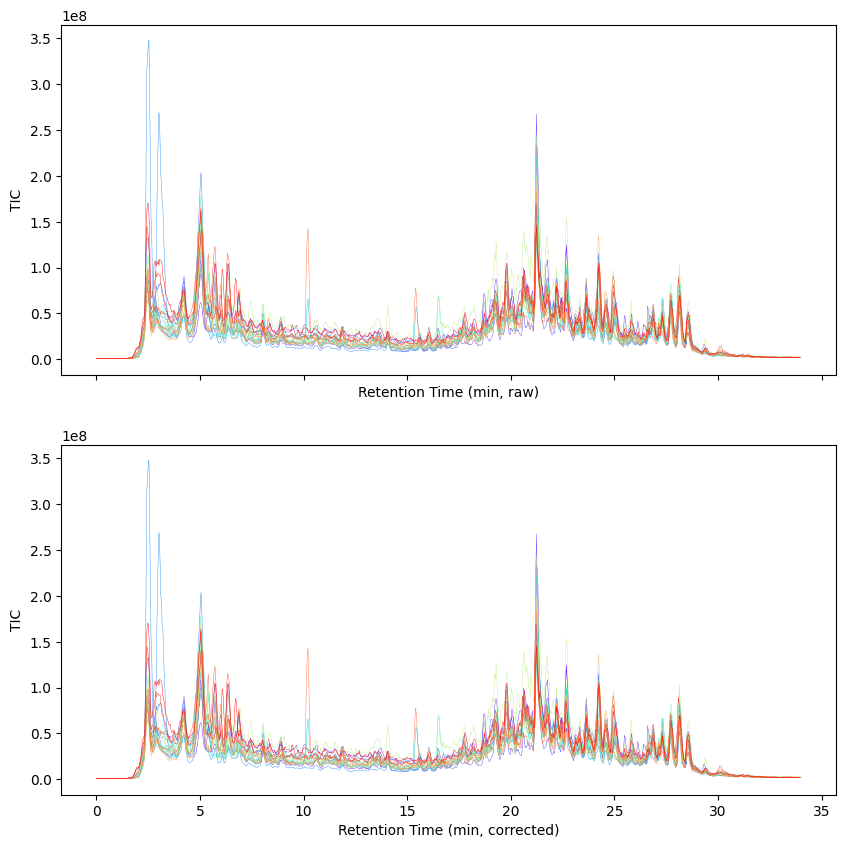

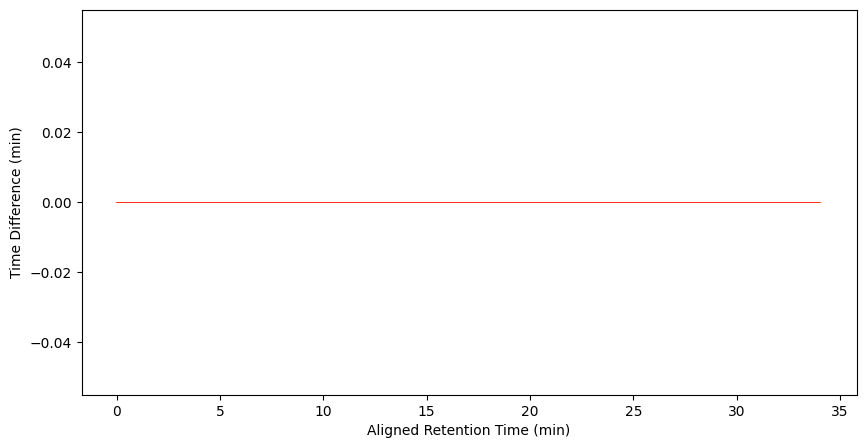

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
from corems.mass_spectra.input.corems_hdf5 import ReadCoreMSHDFMassSpectraCollection
from corems.mass_spectra.calc.lc_calc import PHCalculations, find_closest

# Set the path to the collection of LCMS runs (previously processed)
collection_path = Path(
    "/Users/cies677/sandbox/corems/support_code/nmdc/lipidomics/curr/processed/pos"
    )
# Path to manifest file
manifest_file = collection_path / "manifest_curr.csv"
# This file will need to be created by the user or helper script?
chromatography_file = collection_path / "long_lipid_gradient_chroma.csv"
    
# Set the number of cores to use for loading the data (the parser is parallelized)
ncores = 8

# Instantiate the parser
parser = ReadCoreMSHDFMassSpectraCollection(
    folder_location = collection_path,
    manifest_file = manifest_file,
    chromatography_file = chromatography_file,
    cores = ncores
)
print(
    "Loading LCMS collection with", 
    len(parser.manifest), 
    "samples using", 
    ncores, 
    " cores"
)

# Load the LCMS collection (minimally load the data)
start_time = time.time()
lcms_collection = parser.get_lcms_collection(
    load_raw=False, 
    load_light=True
    )
print(
    "Time to load LCMS collection ", 
    time.time() - start_time, 
    "seconds -", 
    len(lcms_collection), 
    " LCMS runs and ", 
    ncores, 
    " cores"
)
#10s for 7 samples, 10 cores; 162s for 70 samples, 10 cores

# Set flag to call _drop_isotopologue() when running _check_mass_features_df()
lcms_collection.parameters.lcms_collection.drop_isotopologues = True
print(
    "Number of total mass features: ", 
    len(lcms_collection.mass_features_dataframe)
)

# Align the LCMS runs between each other
print("Aligning LCMS collection")
start_time = time.time()
lcms_collection.align_lcms_objects()
print(
    "Time to align LCMS collection: ", 
    time.time() - start_time, 
    "seconds"
)
#1.5s for 7 samples; 15s for 70 samples

# Make some plots 
lcms_collection.plot_tics(type="both")
lcms_collection.plot_alignments()
# TODO: Think about other plots that would be useful to have here for assessing the quality of the data and alignment

# Make consensus mass features from the consolidated mass features
start_time = time.time()
        
## Inconsistently getting a repeated RuntimeWarning: Mean of empty slice
## return np.nanmean(a, axis, out = out, keepdims = keepdims)
## Should check what causes this, make sure output is understood, and if
## yes suppress the warning

In [2]:
lcms_collection.add_consensus_mass_features()
# THIS FUNCTION NEEDS WORK AND NEEDS MECHANISM TO EVALUATE THE RESULTS (plots? reports?)

print(
    "Time to roll up consensus mass features: ", 
    time.time() - start_time, 
    "seconds -", 
    len(lcms_collection.mass_features_dataframe), 
    " total mass features", 
    ncores, 
    " cores"
)

#TODO: Add code to load and save information about chromatographic settings
#TODO: Add code to save and load collection to HDF5 file
#TODO: Add code to plot a consensus mass feature

Time to roll up consensus mass features:  218.44262504577637 seconds - 151007  total mass features 8  cores


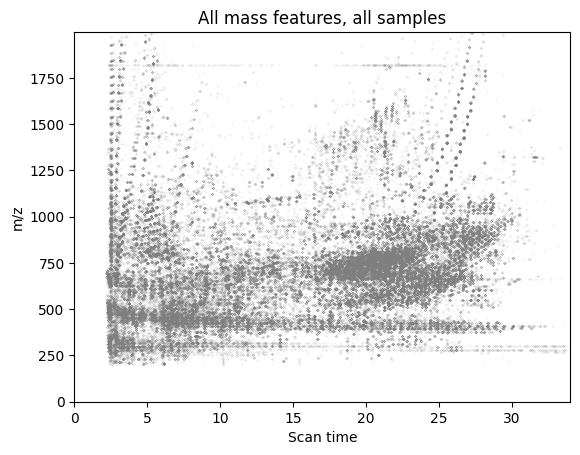

In [3]:
df = lcms_collection.mass_features_dataframe.copy()
## generate mass feature figure
fig = plt.figure()
plt.scatter(
    df.scan_time_aligned, #switched to aligned b/c aligned is the only scan time in the summary
    df.mz,
    c = 'tab:gray',
    alpha = 0.75, ## ask katherine about how we want this to look
    s = 0.005 ## ask katherine about how we want this to look
)

#plt.legend(loc = 'lower center', bbox_to_anchor = (0.5, -0.25), ncol = 2)
plt.xlabel('Scan time')
plt.ylabel('m/z')
plt.ylim(0, np.ceil(np.max(df.mz)))
plt.xlim(0, np.ceil(np.max(df.scan_time)))
plt.title('All mass features, all samples')
plt.show()

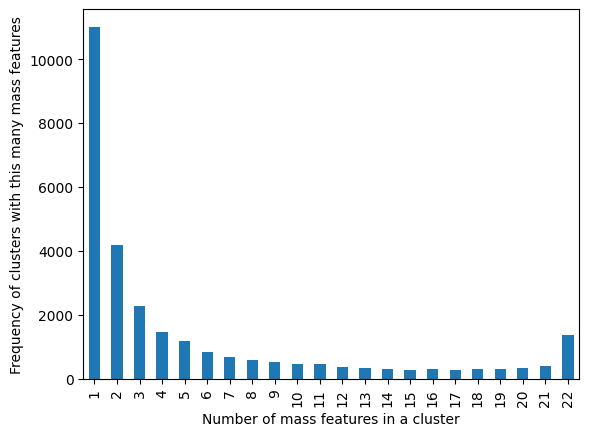

In [4]:
sum_data = lcms_collection.cluster_summary_dataframe
freq_fig, ax = plt.subplots()
sum_data.sample_id_count.value_counts().sort_index().plot(ax = ax, kind = 'bar')
plt.xlabel('Number of mass features in a cluster')
plt.ylabel('Frequency of clusters with this many mass features')
#hist = plt.figure(figsize = (20, 2))
#plt.hist(df.cluster, bins = df.cluster.unique().shape[0])
#plt.xlim(0, np.ceil(np.max(df.cluster.unique())))
#plt.ylim(0, 5)
plt.show()

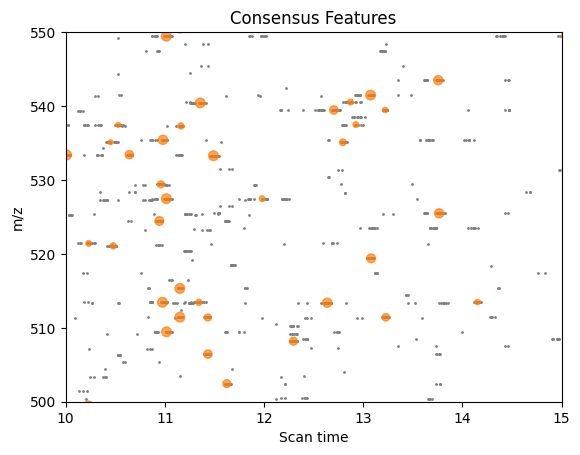

In [8]:
sum_df = lcms_collection.cluster_summary_dataframe.copy()
trunc_df = sum_df[sum_df.sample_id_count > 10]

## generate mass feature figure
fig = plt.figure()
plt.scatter(
    df.scan_time_aligned,
    df.mz,
    c = 'tab:gray',
    s = 1 ## larger dots when scaled in
)

plt.scatter(
    trunc_df.scan_time_aligned_median,
    trunc_df.mz_median, 
    c = 'tab:orange',
    alpha = 0.7, 
    s = (trunc_df.sample_id_count**2)/10
)

## add a scale bar for the orange dots when zoomed in
plt.xlabel('Scan time')
plt.ylabel('m/z')
#plt.ylim(0, np.ceil(np.max(df.mz)))
#plt.xlim(0, np.ceil(np.max(df.scan_time)))
plt.ylim(500, 550)
plt.xlim(10, 15)

plt.title('Consensus Features')
plt.show()

## 3rd option: also just map of consensus/ also can zoom in